In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = "retina"
import shapely # map-rendering library
import numpy as np
import fiona # enging for reading more robust data files
import contextily as cx
import os

In [2]:
os.chdir("/users/sankarana/MinGenResources-DFW")

In [3]:
# 2020 block data
#block_groups = gpd.read_file("Census_Data/tl_2020_48_bg.shp", engine="fiona")

In [4]:
#dallas_county_block_groups = block_groups[block_groups['COUNTYFP']=='113']
#dallas_county_block_groups.to_file("dallas_county_block_groups.geojson")

In [5]:
dallas_county_block_groups = gpd.read_file("Census_Data/dallas_county_block_groups.geojson")

In [6]:
dallas_county_block_groups = dallas_county_block_groups.rename(columns={"GEOID": "GEO_ID"})

In [7]:
dallas_county_block_groups = dallas_county_block_groups[["GEO_ID", "INTPTLAT", "INTPTLON", "geometry"]]

Age of Population

In [8]:
age = pd.read_csv("Census_Data/age.csv")
age["GEO_ID"] = age["GEO_ID"].str[9:]
age = age[["GEO_ID", "P15_001N", "P15_002N", "P15_003N"]]

In [9]:
age = age.rename(columns={"P15_001N": "Total", "P15_002N": "Children", "P15_003N": "Adults"})
age = age.drop(labels = 0, axis = 0)

In [10]:
#dallas_county_blocks.head()
#age.head()

In [11]:
geo_age = dallas_county_block_groups.merge(age, on="GEO_ID", how="left")

In [12]:
#geo_age.columns
#geo_age.info()

In [13]:
geo_age["Total"] = pd.to_numeric(geo_age["Total"])
geo_age["Children"] = pd.to_numeric(geo_age["Children"])
geo_age["Adults"] = pd.to_numeric(geo_age["Adults"])

In [14]:
geo_age["percent_child"] = geo_age["Children"]/geo_age["Total"]*100

In [15]:
geo_age = geo_age.to_crs("EPSG:3857")

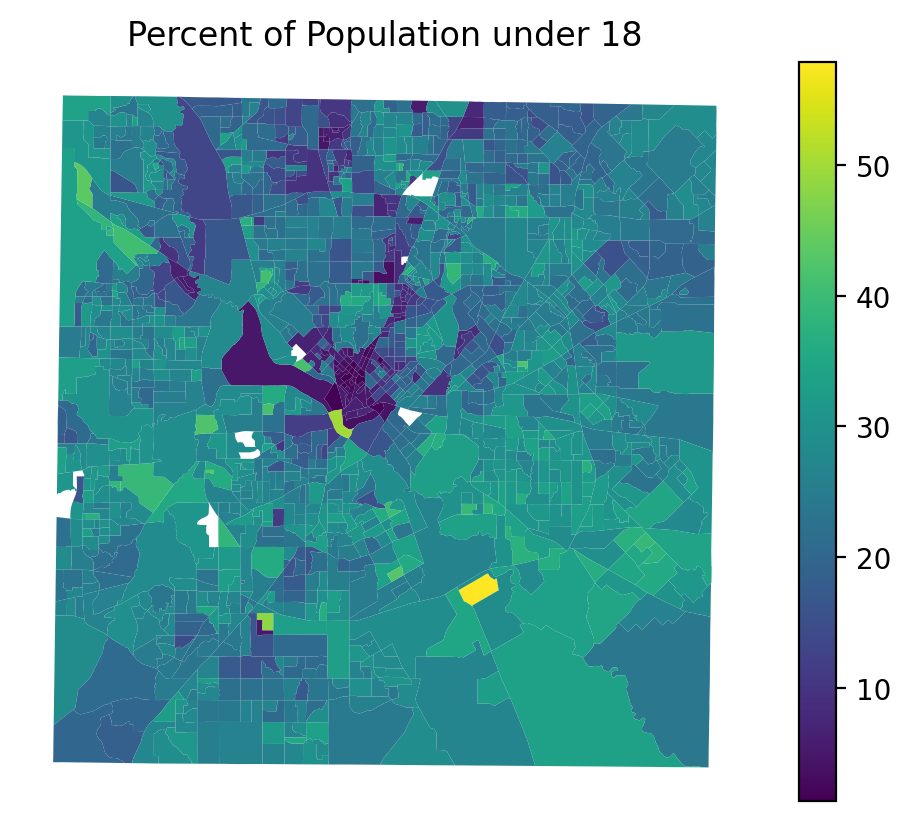

In [16]:
ax = geo_age.plot(column = "percent_child", legend = True)
#cx.add_basemap(ax)
ax.set_title("Percent of Population under 18")
ax.set_axis_off();

In [17]:
#geo_age["percent_child"].sort_values(ascending = False)
#geo_age.loc[29205]

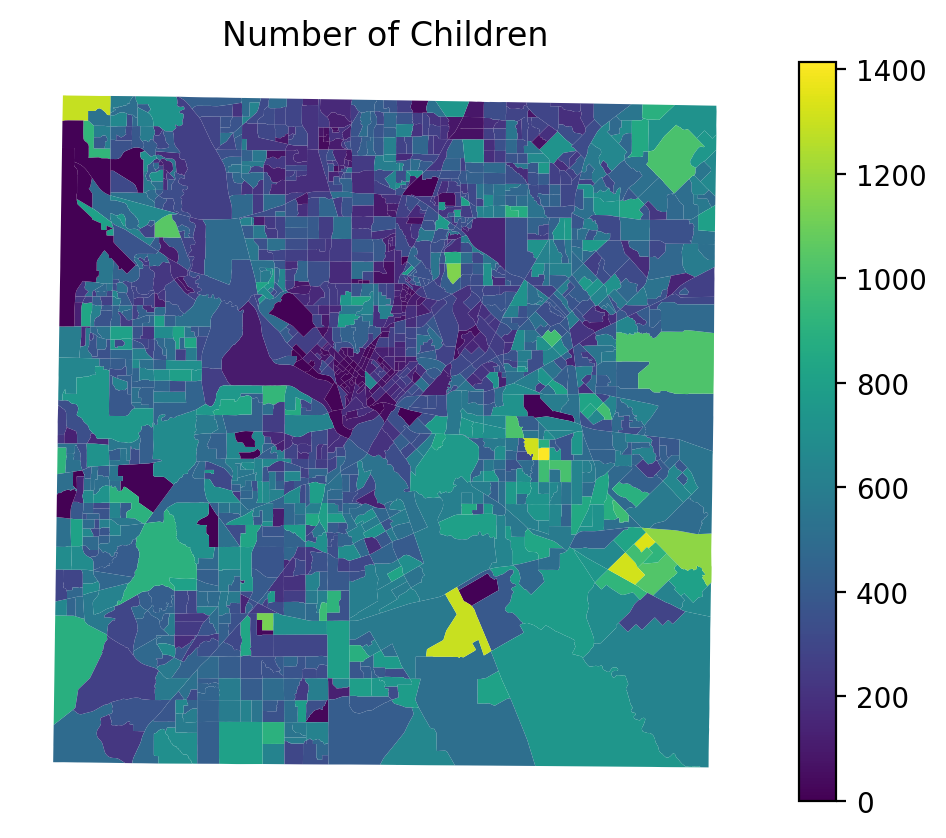

In [18]:
ax = geo_age.plot(column = "Children", legend = True)
#cx.add_basemap(ax)
ax.set_title("Number of Children")
ax.set_axis_off();

In [19]:
#geo_age["Children"].sort_values(ascending = False)
#geo_age.loc[6050]

In [20]:
#test = geo_age.drop(labels = 6050, axis = 0)

In [21]:
#ax = test.plot(column = "percent_child", legend = True)
#cx.add_basemap(ax)
#ax.set_title("Percent of Population under 18")
#ax.set_axis_off();

Median Income

In [22]:
income = pd.read_csv("Census_Data/median_income.csv")

In [23]:
income["GEO_ID"] = income["GEO_ID"].str[9:]

In [24]:
income = income[["GEO_ID", "B19013_001E"]]

In [25]:
income = income.rename(columns={"B19013_001E": "Median_Income"})
income = income.drop(labels = 0, axis = 0)

In [26]:
geo_income = dallas_county_block_groups.merge(income, on="GEO_ID", how="left")

In [27]:
#geo_income["Median_Income"].value_counts()
geo_income = geo_income.replace('-', pd.NA)
geo_income = geo_income.replace('250,000+', "250000")
#geo_income = geo_income.replace(',', "")
#geo_income["Median_Income"].value_counts()

In [28]:
geo_income["Median_Income"] = pd.to_numeric(geo_income["Median_Income"])

In [29]:
geo_income = geo_income.to_crs("EPSG:3857")

In [30]:
closest = geo_income.sjoin_nearest(geo_income, exclusive = True, distance_col="distance")

In [31]:
geo_income.isna().sum()

GEO_ID             0
INTPTLAT           0
INTPTLON           0
geometry           0
Median_Income    111
dtype: int64

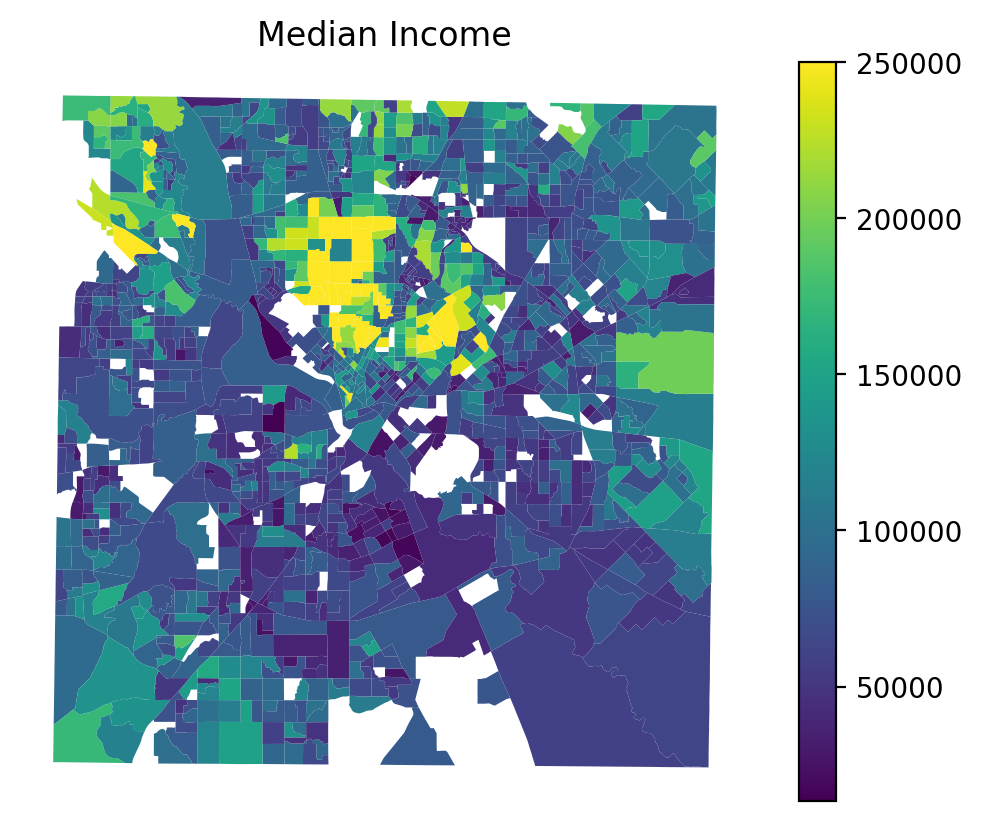

In [32]:
ax = geo_income.plot(column = "Median_Income", legend = True)
#cx.add_basemap(ax)
ax.set_title("Median Income")
ax.set_axis_off();

Poverty

In [33]:
poverty = pd.read_csv("Census_Data/poverty.csv")

In [34]:
poverty["GEO_ID"] = poverty["GEO_ID"].str[9:]

In [35]:
poverty = poverty[["GEO_ID", "B17010_001E", "B17010_002E", "B17010_007E", "B17010_014E", "B17010_020E"]]

In [36]:
poverty = poverty.rename(columns={"B17010_001E": "total", "B17010_002E": "total_below_poverty", "B17010_007E": "married_with_school_children", 
                                 "B17010_014E": "male_with_school_children", "B17010_020E": "female_with_school_children"})

In [37]:
poverty = poverty.drop(labels = 0, axis = 0)

In [38]:
geo_poverty = dallas_county_block_groups.merge(poverty, on="GEO_ID", how="left")

In [39]:
geo_poverty["total"] = pd.to_numeric(geo_poverty["total"])
geo_poverty["total_below_poverty"] = pd.to_numeric(geo_poverty["total_below_poverty"])
geo_poverty["married_with_school_children"] = pd.to_numeric(geo_poverty["married_with_school_children"])
geo_poverty["male_with_school_children"] = pd.to_numeric(geo_poverty["male_with_school_children"])
geo_poverty["female_with_school_children"] = pd.to_numeric(geo_poverty["female_with_school_children"])

In [40]:
geo_poverty = geo_poverty.to_crs("EPSG:3857")

In [41]:
geo_poverty["percent_below"] = geo_poverty["total_below_poverty"]/geo_poverty["total"]*100

In [42]:
geo_poverty["total_school_children"] = (geo_poverty["married_with_school_children"]+
                                geo_poverty["male_with_school_children"]+
                                geo_poverty["female_with_school_children"])

In [43]:
geo_poverty["percent_below_children"] = (geo_poverty["married_with_school_children"]+
                                geo_poverty["male_with_school_children"]+
                                geo_poverty["female_with_school_children"])/geo_poverty["total"]*100

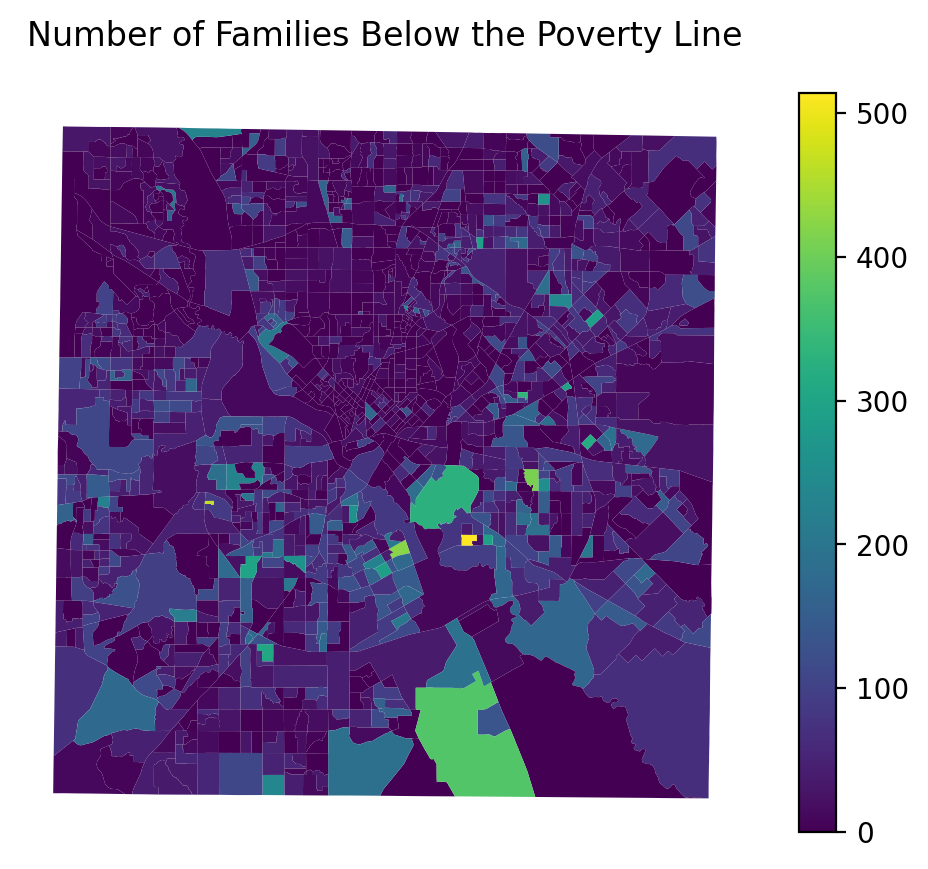

In [44]:
ax = geo_poverty.plot(column = "total_below_poverty", legend = True)
#cx.add_basemap(ax)
ax.set_title("Number of Families Below the Poverty Line")
ax.set_axis_off();

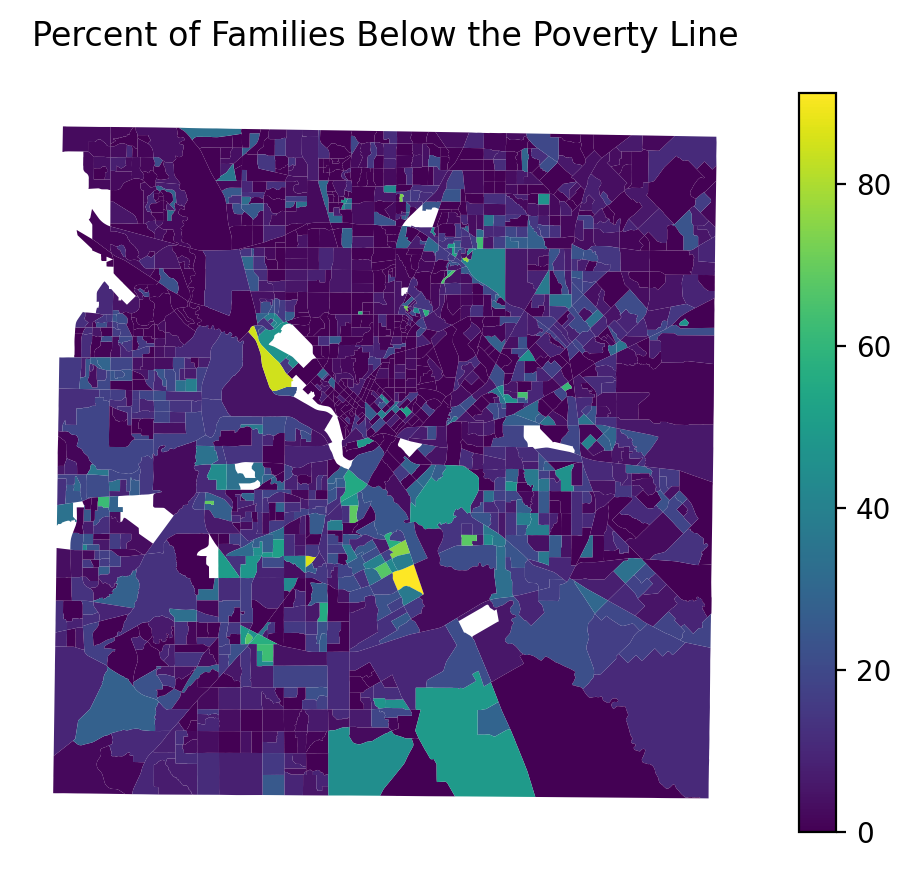

In [45]:
ax = geo_poverty.plot(column = "percent_below", legend = True)
#cx.add_basemap(ax)
ax.set_title("Percent of Families Below the Poverty Line")
ax.set_axis_off();

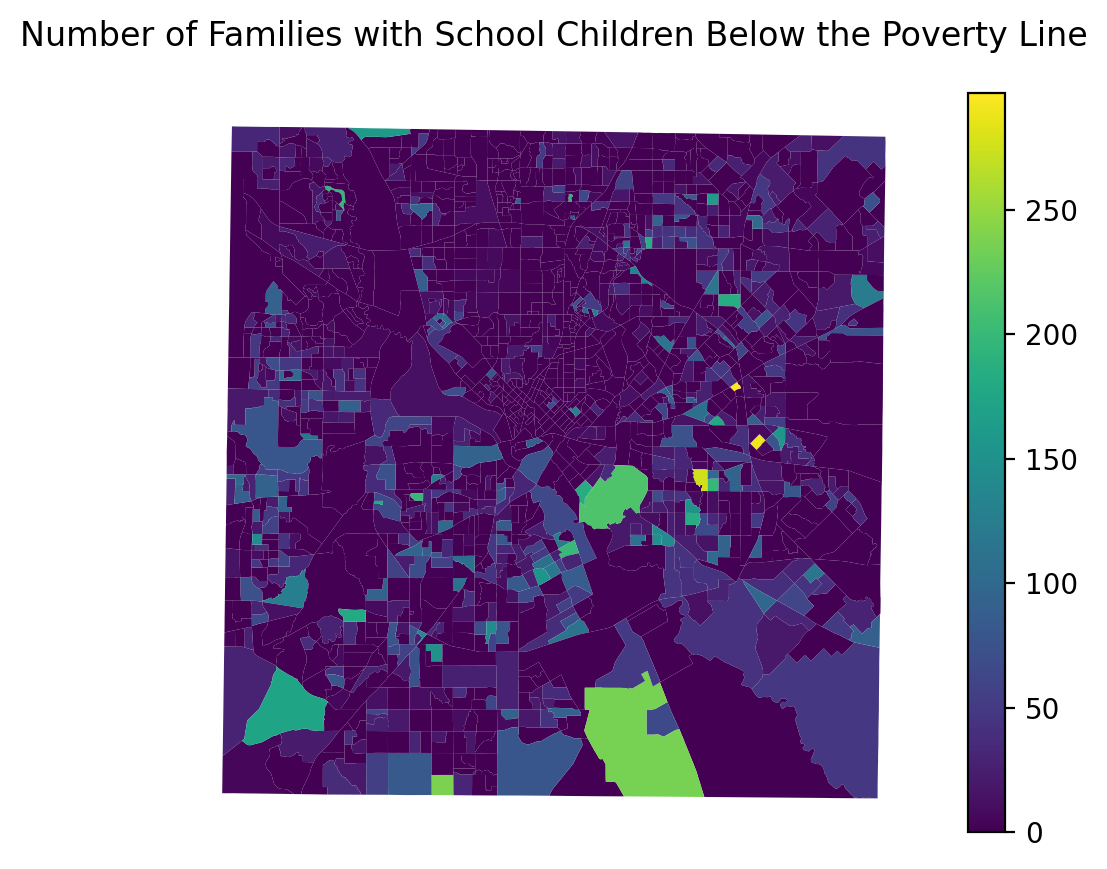

In [46]:
ax = geo_poverty.plot(column = "total_school_children", legend = True)
#cx.add_basemap(ax)
ax.set_title("Number of Families with School Children Below the Poverty Line")
ax.set_axis_off();

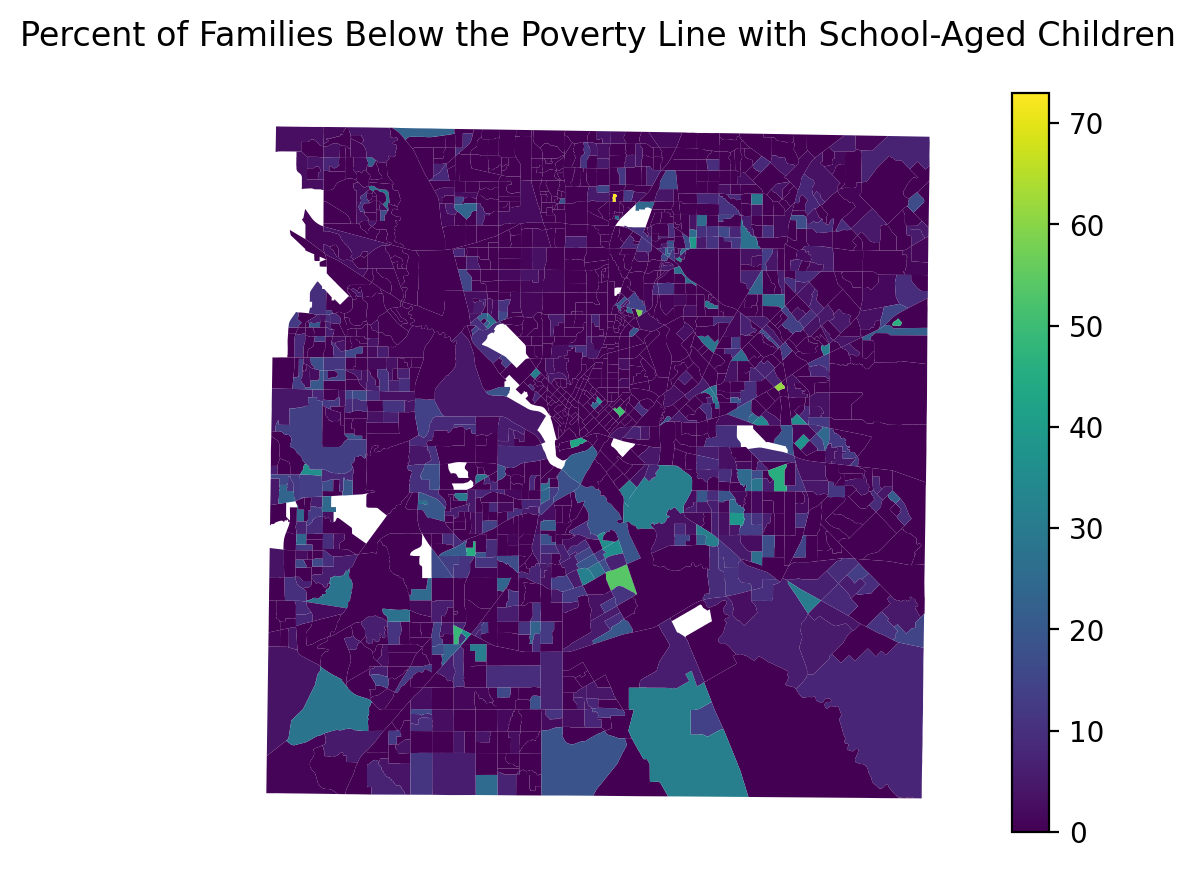

In [47]:
ax = geo_poverty.plot(column = "percent_below_children", legend = True)
#cx.add_basemap(ax)
ax.set_title("Percent of Families Below the Poverty Line with School-Aged Children")
ax.set_axis_off();

In [48]:
#geo_poverty.isna().sum()

In [49]:
#geo_poverty.loc[geo_poverty["percent_below"].isna() == True]
#geo_poverty.loc[85].info

In [50]:
geo_poverty = geo_poverty.replace(np.NaN, 0)

In [51]:
#geo_poverty.isna().sum()

In [52]:
geo_income.to_file("geo_income.geojson")
geo_age.to_file("geo_age.geojson")
geo_poverty.to_file("geo_poverty.geojson")